## Bootstrap Aggregating (Bagging)


- ##### Divides dataset into multiple parts randomly where there might be repeatation between data among different parts.

### Classification

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import make_moons

In [4]:
x, y = make_moons(n_samples=1000, noise=0.2)

In [5]:
df = {"x1":x[:,0], "x2":x[:,1],"y":y}

In [6]:
dataset = pd.DataFrame(df)

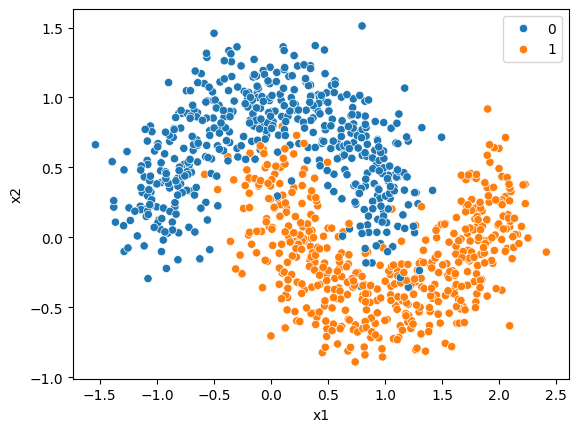

In [7]:
sns.scatterplot(data = dataset, x = "x1", y = "x2", hue = y)
plt.show()

In [8]:
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x_a, y_a, test_size=0.2, random_state=42)

In [17]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [30]:
bg = BaggingClassifier(estimator = SVC(), n_estimators=10)
bg.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",SVC()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [31]:
bg.score(x_train, y_train), bg.score(x_test, y_test)

(0.96875, 0.965)

In [32]:
sv = SVC()
sv.fit(x_train, y_train)
sv.score(x_train, y_train), sv.score(x_test, y_test)

(0.96375, 0.965)

In [112]:
rf = RandomForestClassifier(n_estimators=10, max_depth=8)
rf.fit(x_train, y_train)
rf.score(x_train, y_train), rf.score(x_test, y_test)

(0.9825, 0.955)

### Regression

In [113]:
dataset = pd.read_csv('data/package.csv')

In [114]:
dataset.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [115]:
x = dataset.iloc[:,:-1]
y = dataset["package"]

In [116]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [119]:
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [120]:
bg = BaggingRegressor(estimator = LinearRegression(), n_estimators=50)
bg.fit(x_train, y_train)
bg.score(x_train, y_train), bg.score(x_test, y_test)

(0.7755912247842244, 0.7752162348001281)

In [121]:
rf = RandomForestRegressor(n_estimators=10)
rf.fit(x_train, y_train)
rf.score(x_train, y_train), rf.score(x_test, y_test)

(0.9129685454639809, 0.6391701177294521)